# IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Setup and Data Loading

Instructions:
- Import `pandas`, `seaborn`, and `matplotlib.pyplot`.
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows to confirm it loaded correctly.


In [ ]:
# Your code to import libraries and load data goes here


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# URL for the hotels.csv dataset on GitHub
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/hotels.csv'

# Load the dataset into a pandas DataFrame
df = pd.read_csv(url)

# Display the first few rows to confirm it loaded correctly
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Stakeholder and Business Context

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### Reflection:
1. Who are the key stakeholders for this dataset?
2. What goals might each stakeholder have?
3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response: 🔧
1. Key Stakeholders: Hotel Owners, Hotel Managers, Investors, Marketing Teams, and even the front desk people.

2.
Hotel owners: Maximize Profits
Hotel Managers: Improve Occupancy % and guest satisfaction rates
Investors: Assess Risk through Data Trends and decide whether they want to keep investing thier money
Marketing Teams: Understand which customer groups bring in reliable bookings.
Front Desk: They need to be able to anticipate arrivals and plan for staffing.

3. How do cancellation rates differ by booking lead time, market segment, and hotel type? How can hotel managers use these patterns to reduce cancellations and improve the occupancy rate?




## 3. Explore Data Structure and Quality

### Business framing:  

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.

### Do the following:
- Perform the following 3 checks to see the data quality:
  - Summary the data (e.g., `.info()`, `.describe()`)
  - Find the number of Null values
  - Find the number of duplicate row checks


In [ ]:
# Add code here 🔧


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9404 entries, 0 to 9403
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           9404 non-null   object 
 1   is_canceled                     9404 non-null   int64  
 2   lead_time                       9404 non-null   int64  
 3   arrival_date_year               9404 non-null   int64  
 4   arrival_date_month              9404 non-null   object 
 5   arrival_date_week_number        9404 non-null   int64  
 6   arrival_date_day_of_month       9404 non-null   int64  
 7   stays_in_weekend_nights         9404 non-null   int64  
 8   stays_in_week_nights            9404 non-null   int64  
 9   adults                          9404 non-null   int64  
 10  children                        9404 non-null   int64  
 11  babies                          9404 non-null   int64  
 12  meal                            94

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,7069.000000,1011.000000,9404.000000,9404.000000,9404.000000,9404.000000
mean,0.248299,79.326244,2015.156104,37.026584,15.515313,1.155040,3.078690,1.864738,0.095279,0.015419,0.077839,0.419715,0.290196,0.238622,200.990946,219.550940,1.019034,86.843614,0.144938,0.613143
std,0.432049,87.584146,0.443661,11.083421,9.025545,1.124304,2.379227,1.198565,0.393858,0.125781,0.267933,2.726546,1.352679,0.630041,80.330753,104.296474,10.137928,53.759940,0.353264,0.835930
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,8.000000,2015.000000,31.000000,7.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,156.000000,135.000000,0.000000,45.000000,0.000000,0.000000
50%,0.000000,48.000000,2015.000000,38.000000,16.000000,1.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,223.000000,0.000000,71.550000,0.000000,0.000000
75%,0.000000,118.000000,2015.000000,45.000000,23.000000,2.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,241.000000,286.000000,0.000000,120.600000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,13.000000,33.000000,55.000000,10.000000,2.000000,1.000000,26.000000,26.000000,17.000000,468.000000,511.000000,122.000000,508.000000,2.000000,5.000000


In [4]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [5]:
df.duplicated().sum()

np.int64(1674)

### Reflection:
1. Name at least one structure issue you’ve found (e.g., missing values, formatting problems).
2. How can you fix this structural issue?

### ✍️ Your Response: 🔧
1. One structure issue is the missing values. The country column has 266 missing values, the agent column has 2,335 missing values, and the company column has 8,393 missing values. I also found that there were 1,674 duplicate rows, which could also affect the accuracy of the analysis by counting the same information multiple times.

2. I could label the missing country values as "unknown," which would be using the labeling technique. For agent and company, I would first check whether the missing calues mean that no agent or company was involved in the booking. If it is confirmed as true, then I would label those values . I would also review the duplicated rows to confirm they are repeated records rather than seperate bookings with identical details, then remove all the exact duplicates.



## 4. Univariate Analysis

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### Do the following:
- Select at least 3 individual variables to explore
- Use plots and summary methods (e.g. info(), describe(), etc)  to describe the distribution (hint: we are only looking at the values of one variable, so think of plots you've used in the past that DON'T compare 2 variables.)
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)

Room Price Summary:
count    9404.000000
mean       86.843614
std        53.759940
min        -6.380000
25%        45.000000
50%        71.550000
75%       120.600000
max       508.000000
Name: adr, dtype: float64


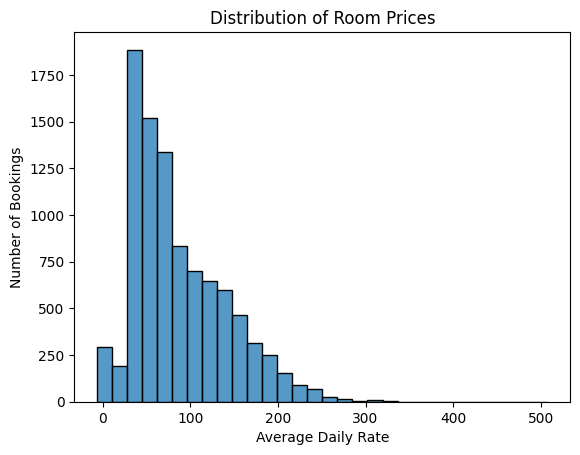

Cancellation Counts:
is_canceled
0    7069
1    2335
Name: count, dtype: int64
Cancellation Percentages:
is_canceled
0    75.17
1    24.83
Name: proportion, dtype: float64


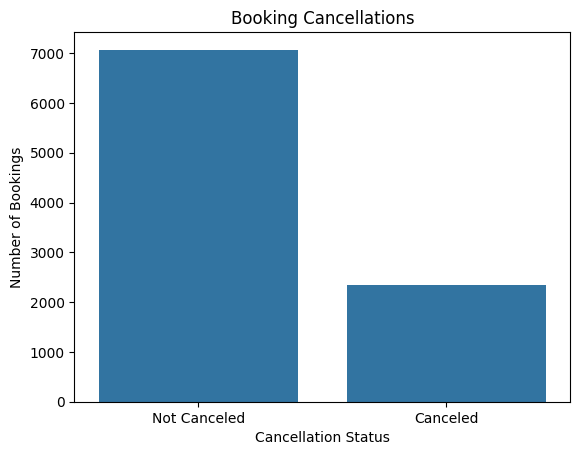

Customer Type Counts:
customer_type
Transient          7031
Transient-Party    1703
Contract            581
Group                89
Name: count, dtype: int64


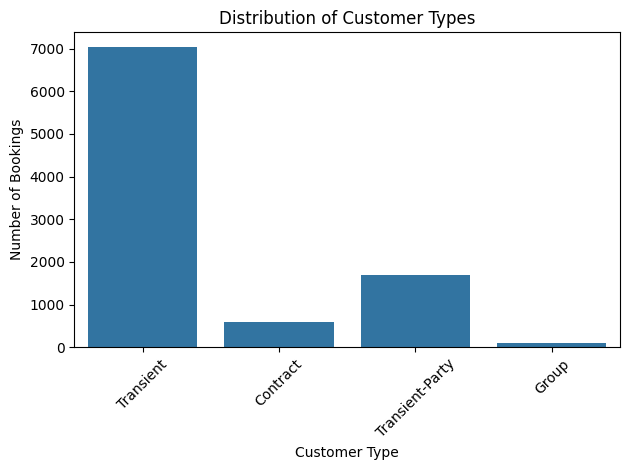

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

#1 Room Price: Average Daily Rate
print ("Room Price Summary:")
print(df["adr"].describe())

sns.histplot(data=df, x="adr", bins=30)
plt.title("Distribution of Room Prices")
plt.xlabel("Average Daily Rate")
plt.ylabel("Number of Bookings")
plt.show()

#2 Cancellations: 0 = Not Canceled, 1 = Canceled
print("Cancellation Counts:")
print(df["is_canceled"].value_counts())

print("Cancellation Percentages:")
print(df["is_canceled"].value_counts(normalize=True).mul(100).round(2))

sns.countplot(data=df, x="is_canceled",order=[0,1])
plt.title("Booking Cancellations")
plt.xticks([0,1], ["Not Canceled", "Canceled"])
plt.xlabel("Cancellation Status")
plt.ylabel("Number of Bookings")
plt.show()

#3 Customer Type
print("Customer Type Counts:")
print(df["customer_type"].value_counts())

sns.countplot(data=df, x="customer_type")
plt.title("Distribution of Customer Types")
plt.xlabel("Customer Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Reflection:
1. Variable 1 – What did you explore and what did you find?
2. Variable 2 – What did you explore and what did you find?
3. Variable 3 – What did you explore and what did you find?

### ✍️ Your Response: 🔧
- **Variable 1 – Room Prices: I explored the average daily rate and found that the distribution is skewed to the right, meaning most bookings have lower rates, with a small number of higher rates. I would say 75% of the bookings have rates at or below $120.60, where the maximum booking price is $508. This helps managers understand typical prces and identify when rates are highly unusual.
- **Variable 2 – Cancellations: I found that 24.38% of bookings were cancelled, where 75.17% were not canceled. This is not a statistic that is very alarming and managers should not be concerned with cancellations, since it does not happen that often.
- **Variable 3 – Customer Tupes: I found that Transient was the most common customer type, with 7,031 bookings, while Group was the least common with only 89 bookings. Transient-Party was second, followed by contract. This means that understanding the needs of transient customers should be a priority when deling with marketing and guest services because there are so many of them.


## 5. Bivariate Analysis

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

### Do the following:
- Choose 2 relevant variable pairs (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`)
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships
- Interpret what these relationships could mean for the hotel business

In [ ]:
# Your code to analyze variable relationships (e.g., scatterplots, grouped bars) 🔧


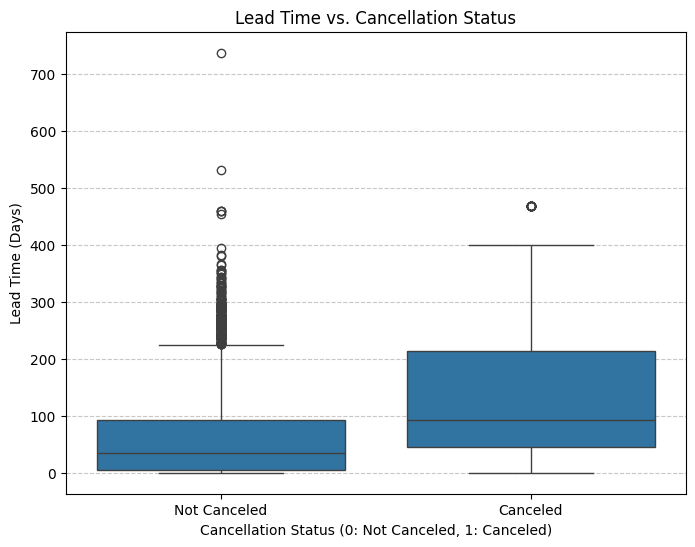


Interpretation for Lead Time vs. Cancellation Status:
This boxplot compares the distribution of lead times for bookings that were not canceled (0) versus those that were canceled (1).
A higher median lead time for canceled bookings would suggest that guests who book further in advance are more prone to cancelling.
Conversely, if lead times for non-canceled bookings are generally shorter, it might indicate that last-minute bookings are more certain.


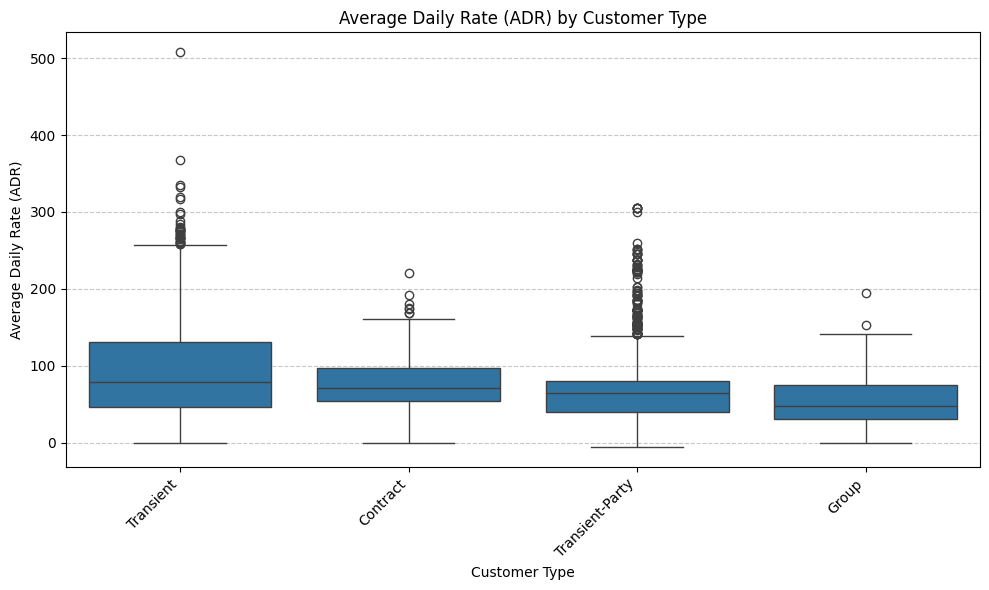


Interpretation for Average Daily Rate (ADR) vs. Customer Type:
This boxplot illustrates the distribution of Average Daily Rates across different customer types (Transient, Transient-Party, Contract, Group).
It helps identify if certain customer segments tend to book more expensive rooms (higher ADR) or more budget-friendly options (lower ADR).
For instance, 'Contract' or 'Group' customers might have negotiated rates, showing a different ADR distribution compared to 'Transient' guests.
Understanding this can inform targeted pricing strategies and marketing efforts for different customer segments.


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Relationship 1: Lead Time vs. Cancellation Status
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='is_canceled', y='lead_time')
plt.title('Lead Time vs. Cancellation Status')
plt.xlabel('Cancellation Status (0: Not Canceled, 1: Canceled)')
plt.ylabel('Lead Time (Days)')
plt.xticks(ticks=[0, 1], labels=['Not Canceled', 'Canceled'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Interpretation for Relationship 1
print("\nInterpretation for Lead Time vs. Cancellation Status:")
print("This boxplot compares the distribution of lead times for bookings that were not canceled (0) versus those that were canceled (1).")
print("A higher median lead time for canceled bookings would suggest that guests who book further in advance are more prone to cancelling.")
print("Conversely, if lead times for non-canceled bookings are generally shorter, it might indicate that last-minute bookings are more certain.")

# Relationship 2: Average Daily Rate (ADR) vs. Customer Type
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='customer_type', y='adr')
plt.title('Average Daily Rate (ADR) by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Average Daily Rate (ADR)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Interpretation for Relationship 2
print("\nInterpretation for Average Daily Rate (ADR) vs. Customer Type:")
print("This boxplot illustrates the distribution of Average Daily Rates across different customer types (Transient, Transient-Party, Contract, Group).")
print("It helps identify if certain customer segments tend to book more expensive rooms (higher ADR) or more budget-friendly options (lower ADR).")
print("For instance, 'Contract' or 'Group' customers might have negotiated rates, showing a different ADR distribution compared to 'Transient' guests.")
print("Understanding this can inform targeted pricing strategies and marketing efforts for different customer segments.")

### Reflection:
1. Relationship 1 – What did you analyze and what insights did you find?
2. Relationship 2 – What did you analyze and what insights did you find?

### ✍️ Your Response: 🔧
- **Relationship 1: Lead Time vs. Cancellation Status**  
  I analyzed the relationship between "lead_time" and "is_canceled" using a boxplot. This showed me that bookings with longer lead times are more likely to be canceled. The median lead time for canceled bookings is much higher than for non-canceled bookings. This means that guests who book their stay further in advance have a higher likelood to change their plans. This could mean that 'early bird' bookings, are good for improving initial occupancy rates, but come with a higher risk of cancellation.

- **Relationship 2: Average Daily Rate (ADR) vs. Customer Type**
  I also analyzed the relationship between "adr" and "customer_type" using a boxplot. Boxplots are nice because they take account for the outliers without influencing the visual too much. This showed that 'Transient' customers typically have the highest and most variable Average Daily Rates (ADR),which means they are often paying standard or dynamic rates. "Contract" and "Group" customers, show lower and more consistent ADRs, which could be due to more negotiated agreements. This is how those group rates are typically handled. "Transient-Party" bookings fall about in the center with these two being the extremes. These customer segments have different pricing sensitivities and booking behaviors, which can impact revenue strategies.

## 6. Problem Complexity and Analytics Framing

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

- Choose one insight from your earlier analysis
- Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)

### Reflection:
1. What was your selected insight?
2. What kind of complexity does it involve?
3. What type of analytics would help, and why?



### ✍️ Your Response: 🔧
1. In my analysis, I found that 24.83% of bookings were canceled, which means that 1 in 4 reservations did not result in a completed stay. My bivariate analysis also showed that canceled bookings had a higher median lead time than bookings that were not canceled. This means that there there is a relationship between booking further in advance and the risk of cancellation.
2. This involves variability because guests book at different times and their booking outcomes differ. This uncertainty makes it difficult for hotel managers to forecast occupancy percentage and revenue for the hotel.

3. Predictive Analytics would help to estimate the likelihood that a future booking will be cancelled using lead time and other variables. These predictions could also help hotel managers plan for staffing and help anticipate what rooms are going to be occupied at any given time.



## 7. Final Takeaways and Recommendations

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

### Reflection:
- 1. What patterns or trends stood out?
- 2. How do they connect to stakeholder goals?
- 3. What recommendation would you make based on this analysis?
- 4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. I found that 24.38% of bookings were canceled, and canceled bookings had a higher median lead time than bookings that were not cancelled. Transient customers made up the largest customer category. Room Prices were right-skewed, with most bookings at much lower rates and only a few at high rates.

2. These findings help hotel managers understand cancellation risk and plan for staffing/room availability at any given time. Owners and invesotrs can benefit from this by understanding the risks that could affect profitability.

3. I would recommend developing and testing a cancellation prediction model using lead time and other booking details as key variables. If it predicts accurately, then managers could use it to improve forecasts on occupancy. I would also test out reservation reminders for those individuals booking far in advance to see if this affects the completed stay rate. Before anything, the missing values and duplicate records issue needs to be fixed.

4. This relates to my customized learning outcome I created in canvas indirectly. I want to be able to run these statistics, but for ski brands. So, I guess at least now I know how to complete an analysis like this and if I can find the data, I theoretically should be able to run models similar to these ones.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [12]:
!jupyter nbconvert --to html "assignment_05_eda.ipynb"

[NbConvertApp] Converting notebook assignment_05_eda.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 538176 bytes to assignment_05_eda.html
